# Exercise Graph 5
## Your Task:
Implement an *automatic higher or lower game*.

Set the bounds between *1 to 20*. The graph has to keep guessing (maximum guesses should be 7).
If the guess is correct it stops, otherwise we keep looping.

Each time a number is guessed *the hint node should say higher or lower* and the graph should account for this information and adjust its guess accordingly.

*Input:* `{"player_name": "Student", "guesses": [], "attempts": 0, "lower_bound": 1, "upper_bound": 20}`

In [1]:
from typing import Dict, List, TypedDict
import random
from langgraph.graph import StateGraph, END

In [2]:
# We now create an AgentState - shared data structure that keeps track of information as your application runs.

class AgentState(TypedDict):
    player_name: str
    guesses: List[int]
    attempts: int
    lower_bound: int
    upper_bound: int
    message: str
    objective: int     # Number to guess (randomly generated at the start)

In [24]:
def setup_node(state: AgentState) -> AgentState:
    """Node for Greeting and initializing variables"""

    state['message'] = f"Howdy {state['player_name']}! Care for a wee game of number guessing? You don't have a choice."
    state['message'] += f"\nLets see... I have to guess a number from {state['lower_bound']} to {state['upper_bound']}"
    state['guesses'] = []
    state['attempts'] = 0
    state['objective'] = random.randint(1, 20)

    state['message'] += f"\n(the number to guess is {state['objective']})"

    return state

def guess_node(state: AgentState) -> AgentState:
    """Node for guessing the number"""

    state['guesses'].append((state['upper_bound'] + state['lower_bound']) // 2)  # Always guess the midpoint number (rounded down)

    state['attempts'] += 1

    state['message'] += f"\nGUESS {state['attempts']}: {state['guesses'][-1]}"

    return state


def hint_node(state: AgentState) -> AgentState:
    """Gives a hint and readjusts guessing parameters"""

    print(state['guesses'][-1], state['objective'])
    if state['guesses'][-1] == state['objective']:
        state['message'] += " Hey, I found it! Isn't that nice!"
    
    elif state['objective'] < state['guesses'][-1]:
        state['message'] += f" So you're saying it's lower than {state['guesses'][-1]}? How about..."
        state['upper_bound'] = state['guesses'][-1] - 1
    
    elif state['objective'] > state['guesses'][-1]:
        state['message'] += f" So you're saying it's larger than {state['guesses'][-1]}? How about..."
        state['lower_bound'] = state['guesses'][-1] + 1
    
    return state
    
def should_continue(state: AgentState) -> AgentState:
    """Decides whether to continue or stop the loop"""

    if state['guesses'][-1] == state['objective'] or state['attempts'] > 7:
        return 'end'  # break from loop
    
    else:
        return 'continue'  # continue loop

In [25]:
graph = StateGraph(AgentState)

graph.add_node('setup', setup_node)
graph.add_node('guess', guess_node)
graph.add_node('hint', hint_node)

graph.add_edge('setup', 'guess')
graph.add_edge('guess', 'hint')

graph.add_conditional_edges(
    'hint',
    should_continue,
    {
        'continue': 'guess',
        'end': END,
     }
)

graph.set_entry_point('setup')

app = graph.compile()

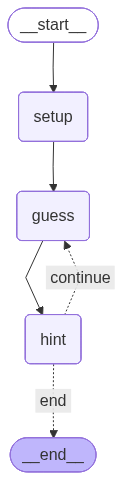

In [26]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [27]:
initial_state_1 = AgentState(player_name='Budiggity Jack', guesses=[], attempts=0, lower_bound=1, upper_bound=20)
answer = app.invoke(initial_state_1)
print(answer)
print(answer['message'])

10 16
15 16
18 16
16 16
{'player_name': 'Budiggity Jack', 'guesses': [10, 15, 18, 16], 'attempts': 4, 'lower_bound': 16, 'upper_bound': 17, 'message': "Howdy Budiggity Jack! Care for a wee game of number guessing? You don't have a choice.\nLets see... I have to guess a number from 1 to 20\n(the number to guess is 16)\nGUESS 1: 10 So you're saying it's larger than 10? How about...\nGUESS 2: 15 So you're saying it's larger than 15? How about...\nGUESS 3: 18 So you're saying it's lower than 18? How about...\nGUESS 4: 16 Hey, I found it! Isn't that nice!", 'objective': 16}
Howdy Budiggity Jack! Care for a wee game of number guessing? You don't have a choice.
Lets see... I have to guess a number from 1 to 20
(the number to guess is 16)
GUESS 1: 10 So you're saying it's larger than 10? How about...
GUESS 2: 15 So you're saying it's larger than 15? How about...
GUESS 3: 18 So you're saying it's lower than 18? How about...
GUESS 4: 16 Hey, I found it! Isn't that nice!


In [24]:
1 - 9*8*7*6/10/10/10/10

0.6976